# GeoBench Burn Scars

In [1]:
import os
from pathlib import Path

import torch
from geobench_v2.datasets.visualization_util import (
    compare_normalization_methods,
    compute_batch_histograms,
    plot_batch_histograms,
    plot_channel_histograms,
    visualize_segmentation_target_statistics,
)

from geobench_v2.datamodules import GeoBenchBurnScarsDataModule
from geobench_v2.datasets import GeoBenchBurnScars
from geobench_v2.datasets.normalization import SatMAENormalizer, ZScoreNormalizer

%load_ext autoreload
%autoreload 2

In [2]:
DATA_ROOT = Path("../../data/burn_scars")

STATS_SATMAE_PATH = os.path.join(DATA_ROOT, "burn_scars_stats_satmae.json")
STATS_CLIP_RESCALE_PATH = os.path.join(DATA_ROOT, "burn_scars_stats_clip_rescale.json")

In [3]:
band_order = GeoBenchBurnScars.band_default_order


datamodule = GeoBenchBurnScarsDataModule(
    img_size=256,
    batch_size=4,
    num_workers=4,
    root=DATA_ROOT,
    band_order=band_order,
    data_normalizer=torch.nn.Identity(),
)
datamodule.setup("fit")

Using provided pre-initialized normalizer instance: Identity
Using provided pre-initialized normalizer instance: Identity


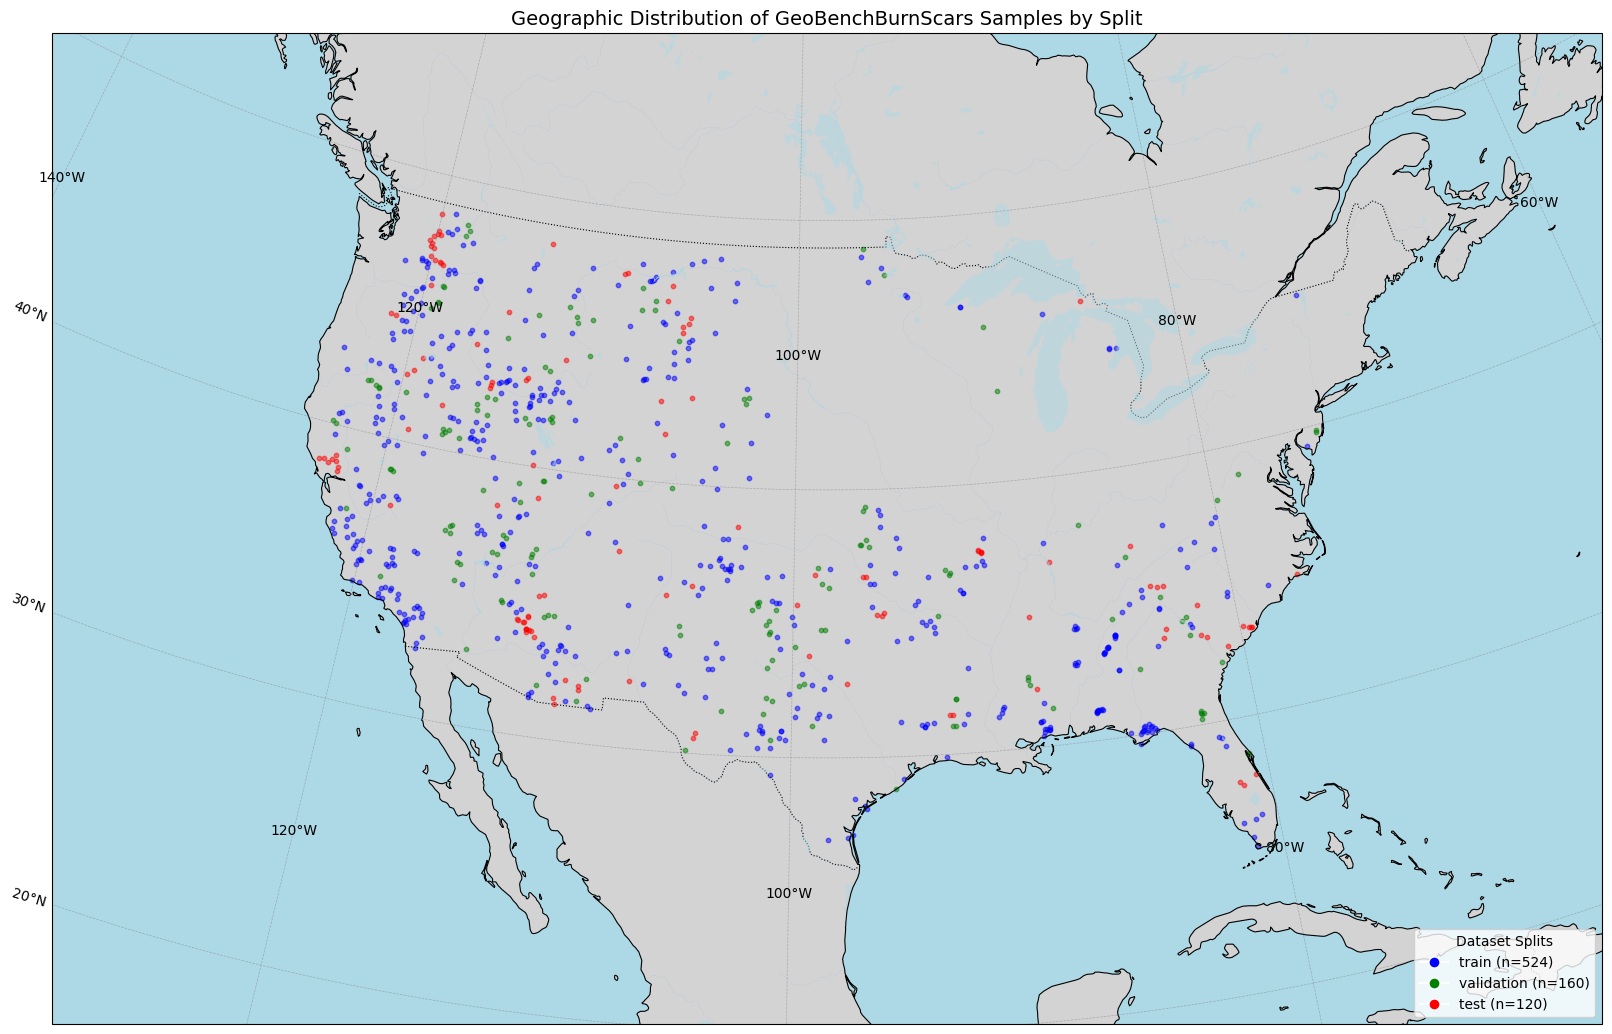

In [4]:
sample_dist_fig = datamodule.visualize_geospatial_distribution()

## Dataset Statistics

Computed over the training dataset.

### Image Dataset Statistics

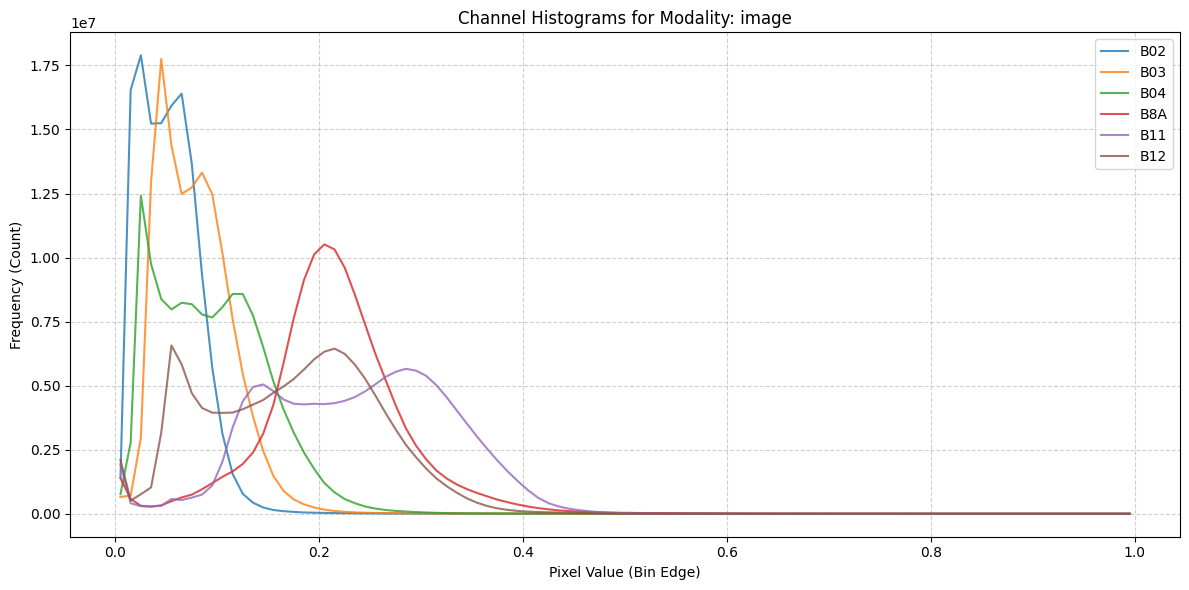

In [5]:
fig = plot_channel_histograms(STATS_SATMAE_PATH)

### Target Statistics

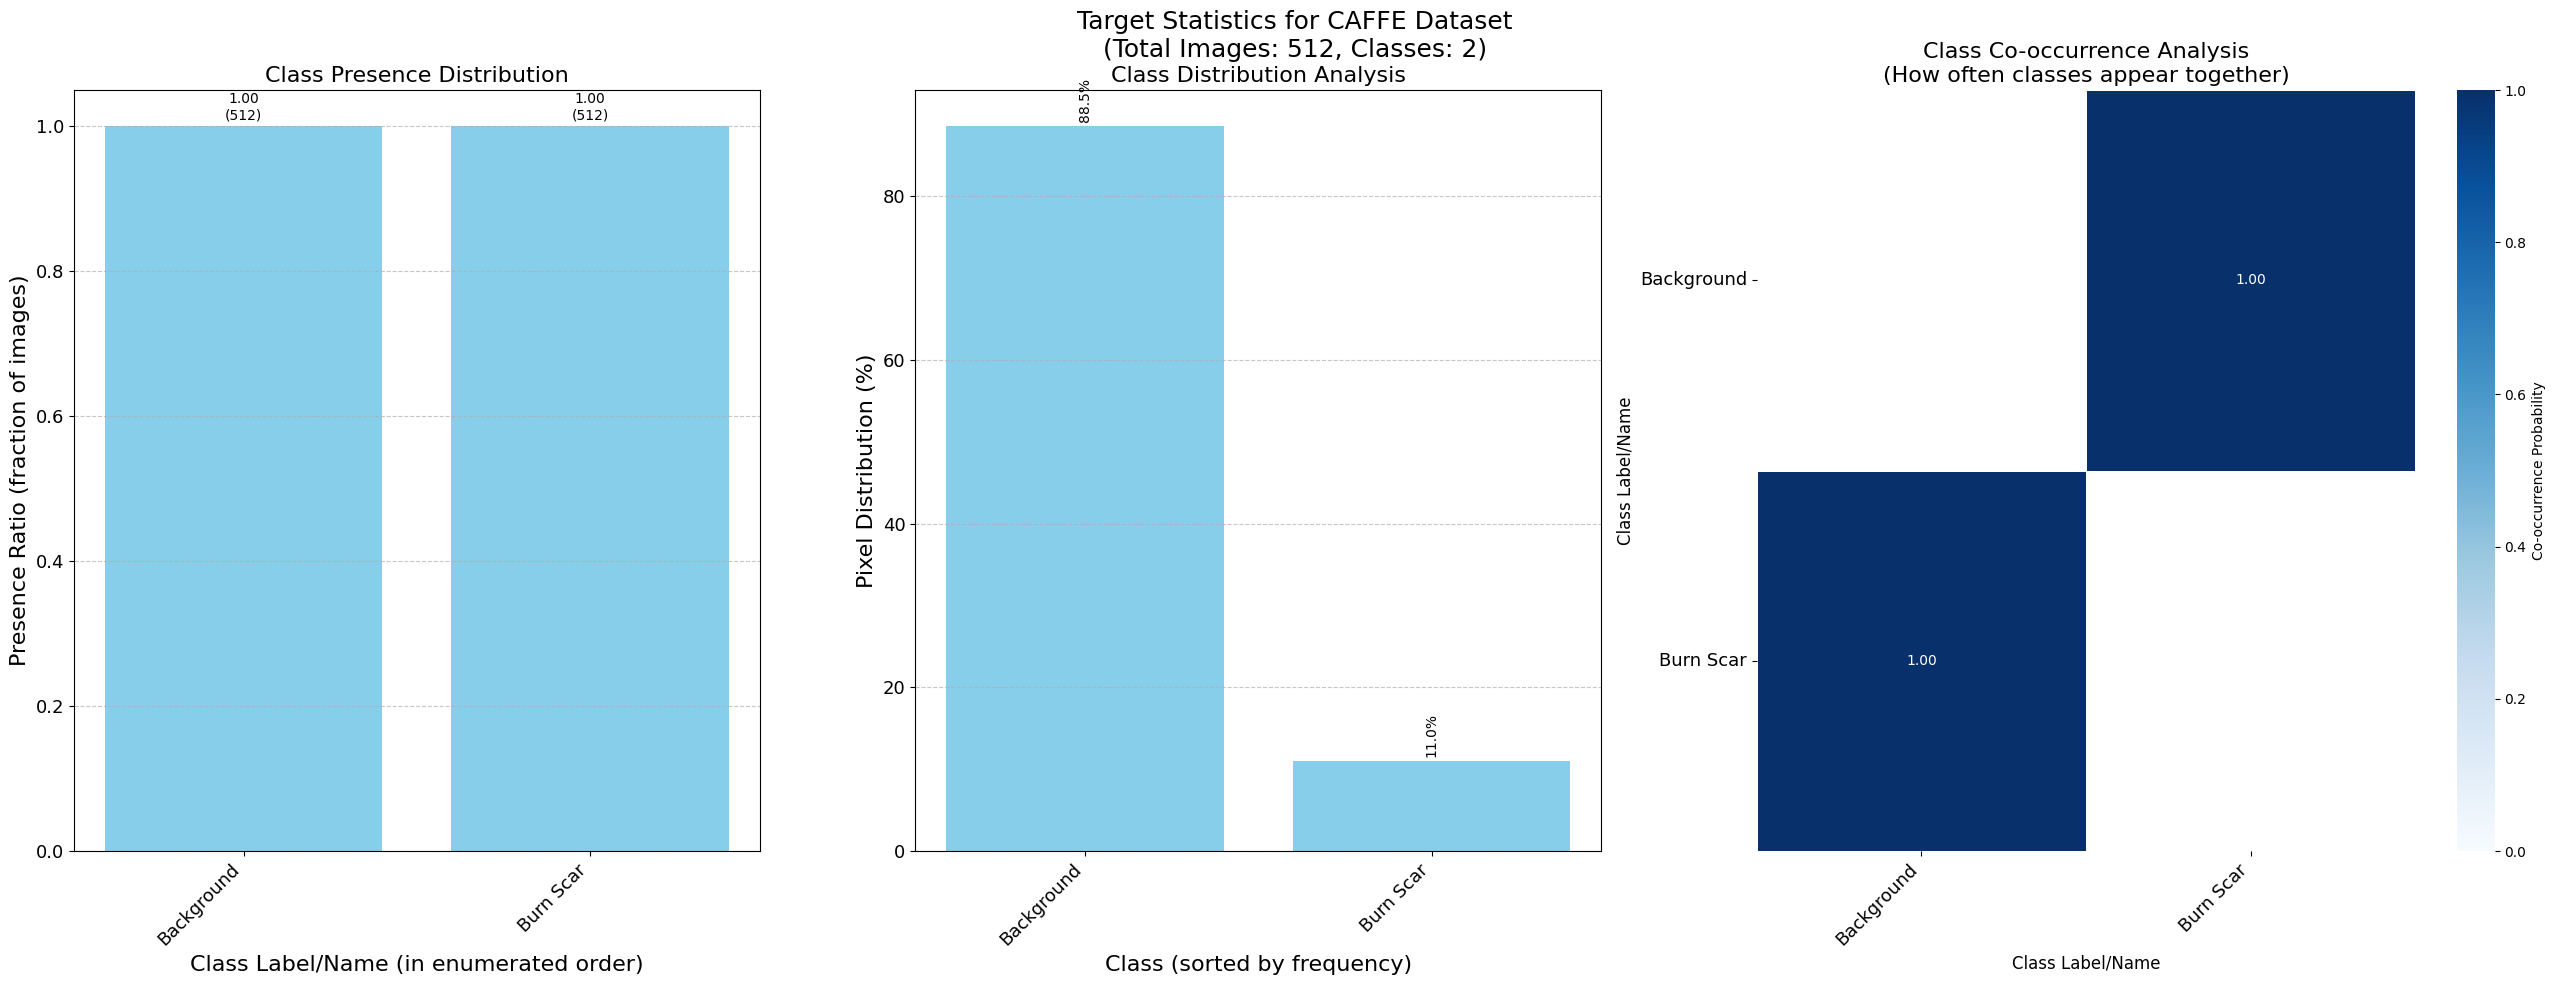

In [6]:
fig = visualize_segmentation_target_statistics(STATS_SATMAE_PATH, "CaFFe")

### Raw Batch Statistics

[<Figure size 1200x500 with 1 Axes>]

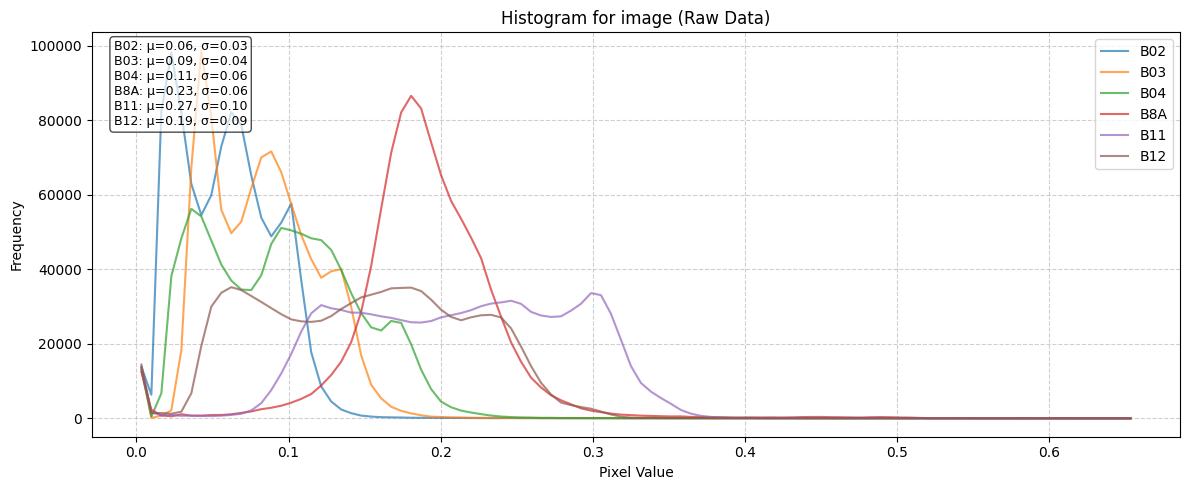

In [7]:
# Get a batch of data from the dataloader
train_dataloader = datamodule.train_dataloader()
raw_batch = next(iter(train_dataloader))

raw_batch_stats = compute_batch_histograms(raw_batch, n_bins=100)


raw_figs = plot_batch_histograms(
    raw_batch_stats, band_order, title_suffix=" (Raw Data)"
)
raw_figs

### Effect of different Normalization Schemes

In [8]:
zscore_normalizer = ZScoreNormalizer(STATS_CLIP_RESCALE_PATH, band_order)
satmae_normalizer = SatMAENormalizer(STATS_SATMAE_PATH, band_order)

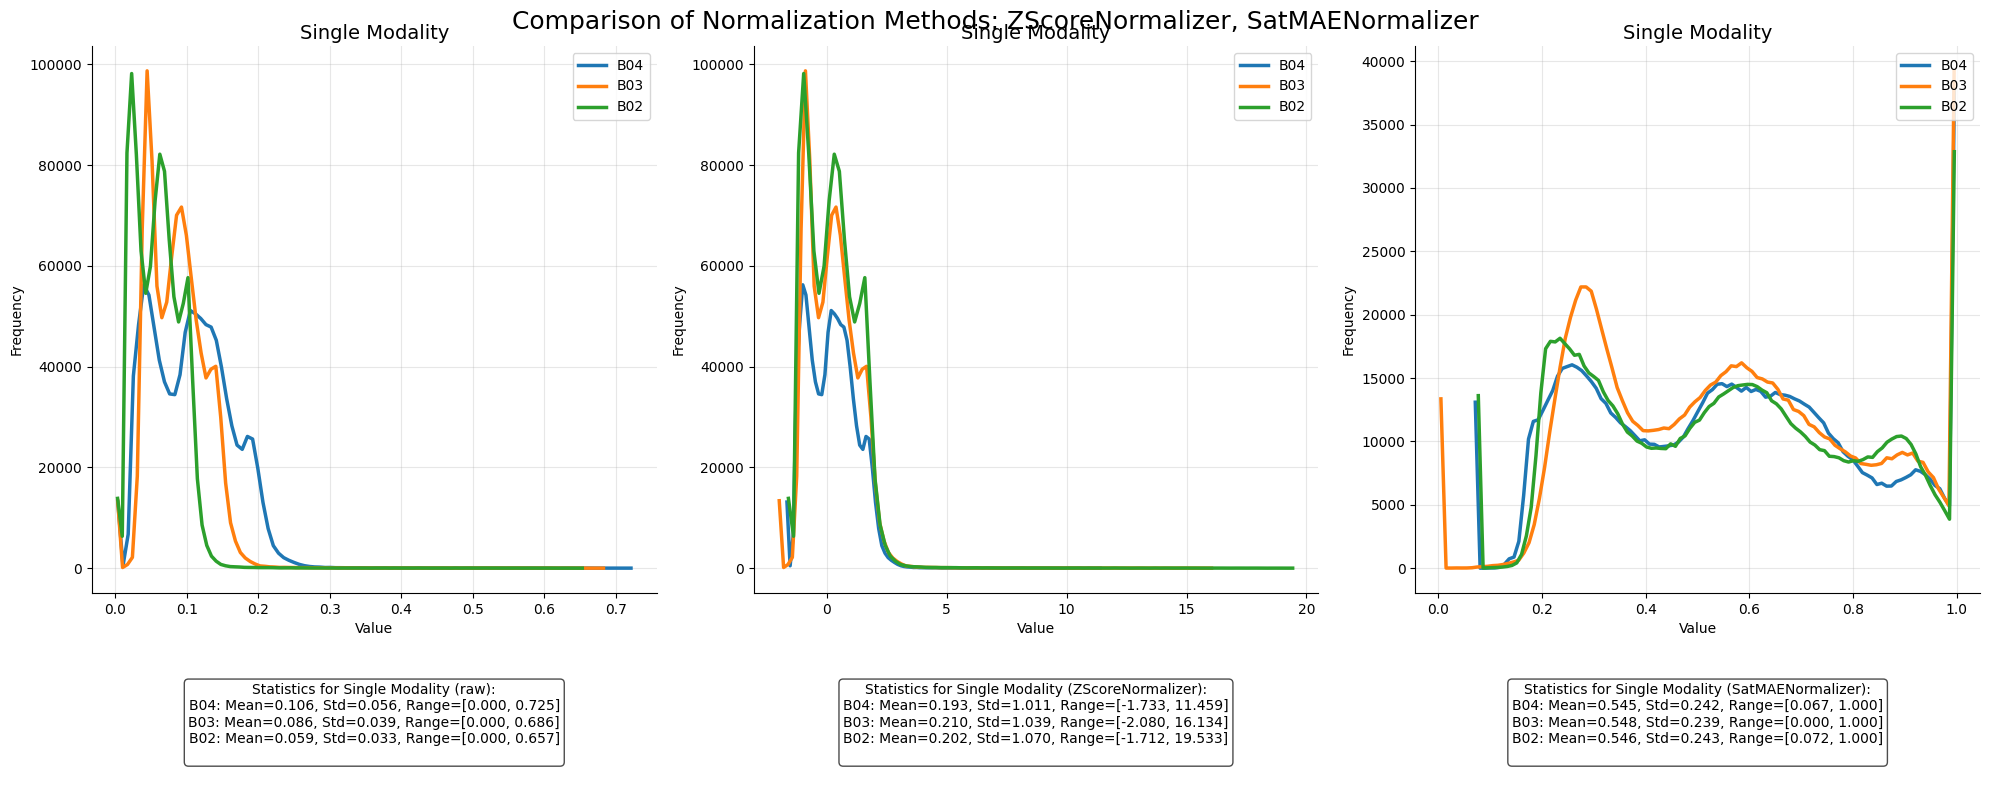

In [9]:
norm_fig, normalized_batches = compare_normalization_methods(
    raw_batch, [zscore_normalizer, satmae_normalizer], datamodule
)

## Visualize Batch Data

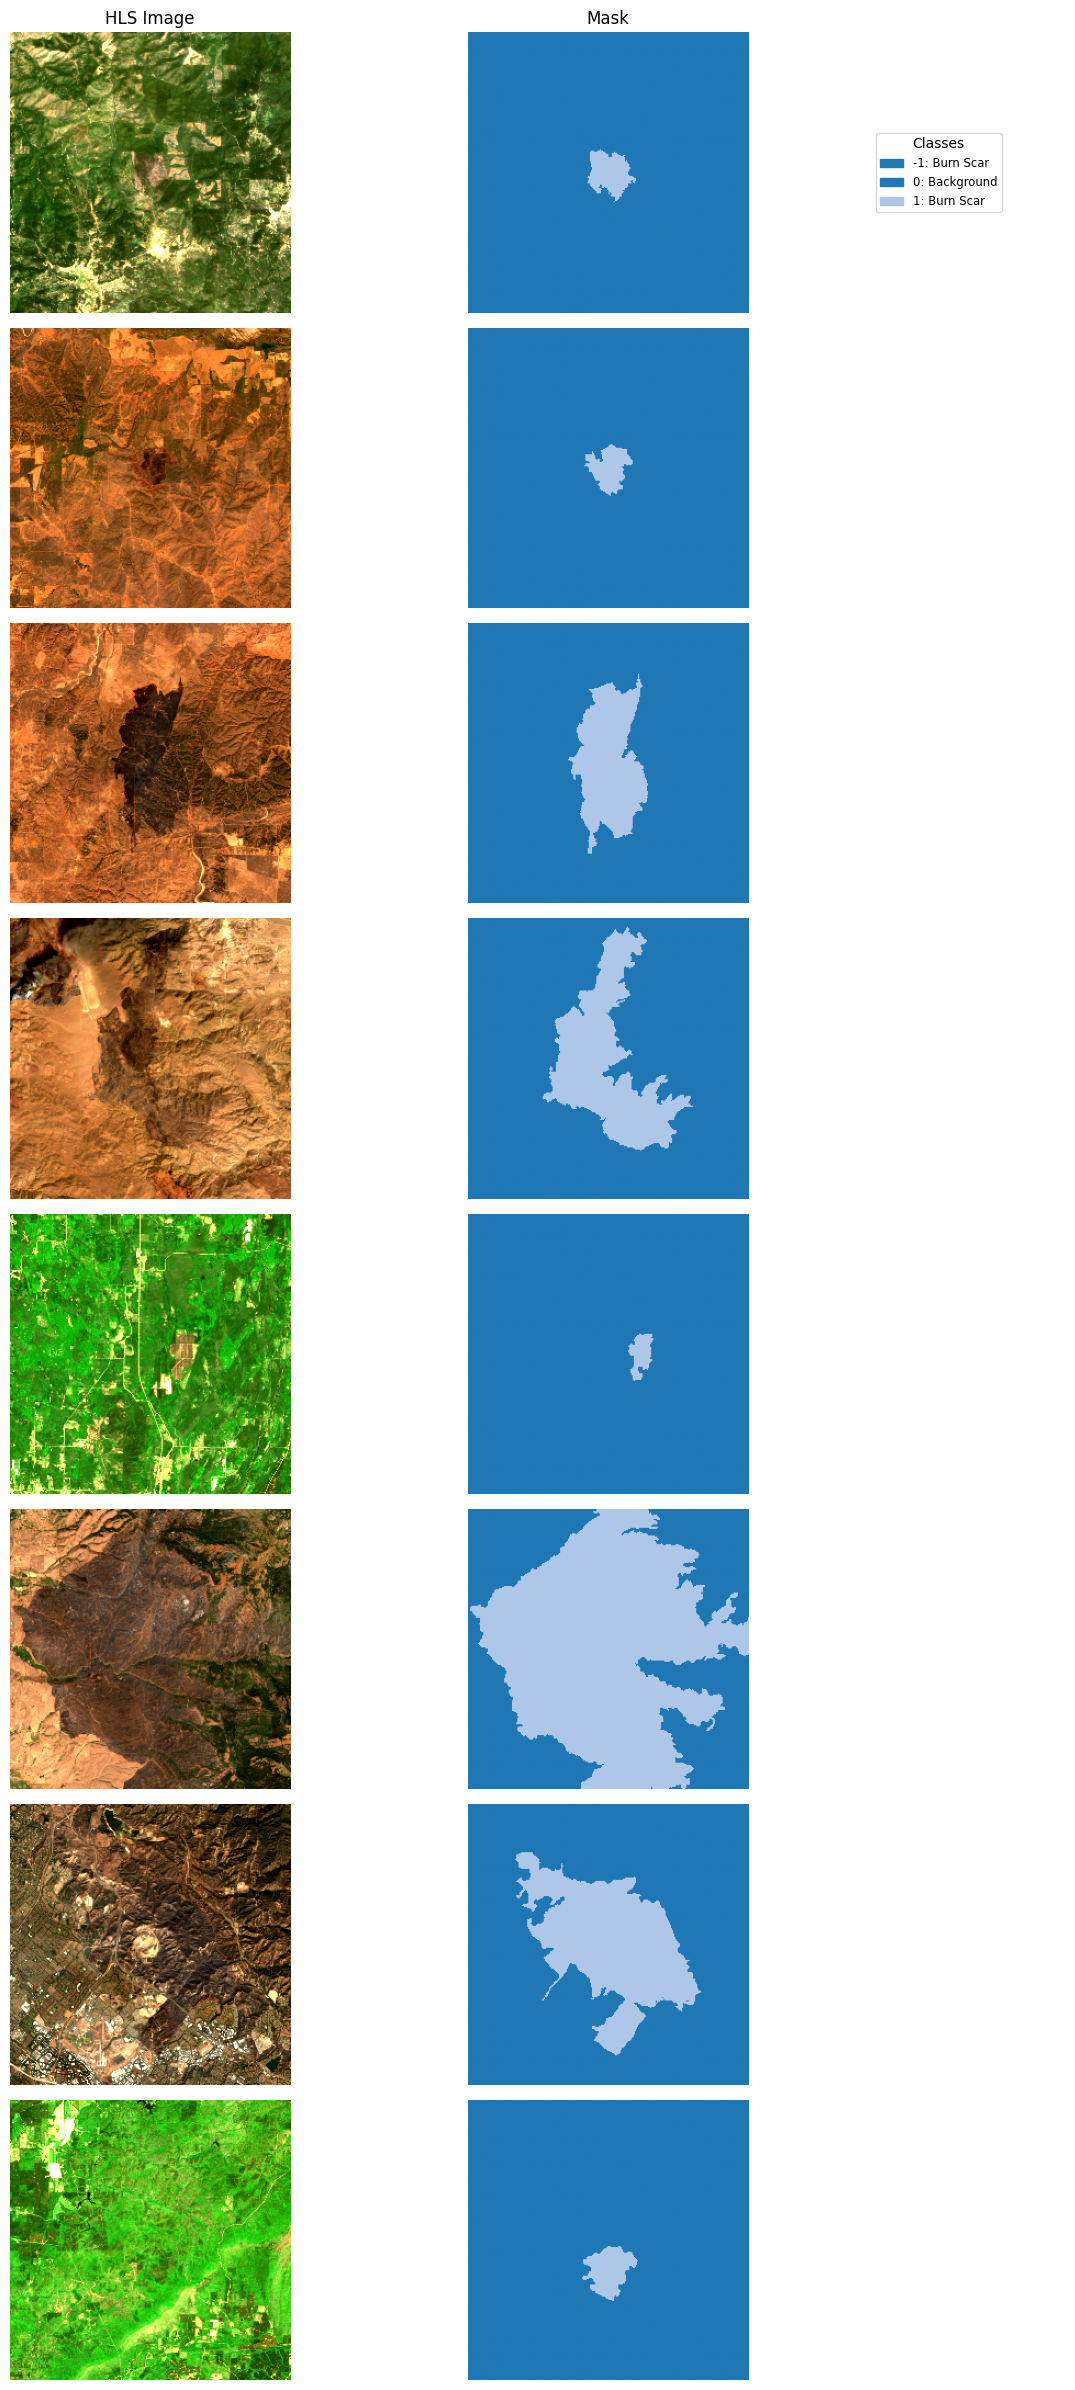

In [10]:
fig, batch = datamodule.visualize_batch()